# 01 — Exploratory Data Analysis
### AI-Generated Bengali Handwritten Signature Detection

EDA on the signature dataset **before** any preprocessing, to understand its structure and
surface shortcuts (image size, format, background, cropping style) a model could exploit
instead of learning genuine signature characteristics.

**Dataset classes**
- `0` — Genuine (human-written) Bengali signature
- `1` — AI-generated Bengali signature (Gemini, QN/Qwen, or GPT)

**Generators**
| Generator | Type | Writer identity |
|---|---|---|
| Gemini | reference-based (uses a genuine writer's signature as reference) | yes — writer folder |
| QN / Qwen | reference-based | yes — writer folder |
| GPT | no-reference (prompted from a Bangla name only) | no |

QN/Qwen is auto-detected below — if you haven't added that folder yet, this notebook still
runs fine on Gemini + GPT only and will just report 0 QN samples.

**What this notebook covers**
1. Configuration & dataset discovery (incl. writer-id consistency check)
2. Building / loading the metadata file
3. Class, writer, and generator counts
4. Image dimension, format, and color-mode survey
5. Background characteristic analysis
6. Sample signature visualization
7. Within-writer variation
8. Duplicate / near-duplicate detection
9. Summary report

## 1. Configuration

Actual folder layout used by this dataset:

```
dataset/
├── genuine/
│   ├── W001/
│   │   ├── W001_01.png
│   │   └── ...
│   └── ...
└── AI/
    ├── gemini/
    │   ├── W001/
    │   │   ├── W001_GEM_01.png
    │   │   └── ...
    │   └── ...
    ├── qn/                     # optional — auto-detected (also tries "qwen")
    │   ├── W055/
    │   │   └── ...
    │   └── ...
    └── gpt/
        ├── GPT_001.png         # flat, no writer subfolders (no-reference generation)
        └── ...
```

If `dataset/metadata.csv` already exists it is loaded directly; otherwise this notebook
builds one by scanning folders.

In [18]:
import os
import warnings
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- EDIT THIS ----
DATASET_ROOT = Path("../dataset")
METADATA_PATH = DATASET_ROOT / "metadata.csv"

GENUINE_DIR = DATASET_ROOT / "genuine"
AI_ROOT = DATASET_ROOT / "AI"
GEMINI_DIR = AI_ROOT / "gemini"
GPT_DIR = AI_ROOT / "gpt"

# QN/Qwen folder name isn't fully settled yet in the raw data -- try both common spellings.
QN_CANDIDATES = [AI_ROOT / "qn", AI_ROOT / "qwen", AI_ROOT / "QN", AI_ROOT / "Qwen"]
QN_DIR = next((p for p in QN_CANDIDATES if p.exists()), None)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

print(f"Dataset root: {DATASET_ROOT.resolve()}")
print(f"genuine/ exists: {GENUINE_DIR.exists()}")
print(f"AI/gemini/ exists: {GEMINI_DIR.exists()}")
print(f"AI/gpt/ exists: {GPT_DIR.exists()}")
if QN_DIR is not None:
    print(f"AI/qn (or qwen)/ found at: {QN_DIR}")
else:
    print("No QN/Qwen folder found yet -- this notebook will report 0 QN samples "
          "(add the folder later and re-run to include it, no code changes needed).")


Dataset root: C:\Users\Maisha\OneDrive\Desktop\ML_Project\Version_2\dataset
genuine/ exists: True
AI/gemini/ exists: True
AI/gpt/ exists: True
AI/qn (or qwen)/ found at: ..\dataset\AI\qwen


## 2. Build / load metadata

Columns: `filename, filepath, label, writer_id, generator, generation_type, reference_used,
reference_based, split`

`reference_based` is the numeric (0/1) form of `reference_used`, matching the metadata schema
in the master research note. `split` is left empty here — writer-level train/val/test
splitting is handled entirely in Notebook 02, to keep this notebook focused on analysis.

In [19]:
def scan_genuine(genuine_dir):
    rows = []
    if not genuine_dir.exists():
        return rows
    for writer_dir in sorted(genuine_dir.iterdir()):
        if not writer_dir.is_dir():
            continue
        writer_id = writer_dir.name
        for f in sorted(writer_dir.iterdir()):
            if f.suffix.lower() in IMAGE_EXTS:
                rows.append({
                    "filename": f.name,
                    "filepath": str(f),
                    "label": 0,
                    "writer_id": writer_id,
                    "generator": "Human",
                    "generation_type": "genuine",
                    "reference_used": "No",
                    "reference_based": 0,
                })
    return rows


def scan_reference_based(gen_dir, generator_name):
    '''Shared scanner for any reference-based, writer-foldered generator (Gemini, QN/Qwen).'''
    rows = []
    if gen_dir is None or not gen_dir.exists():
        return rows
    for writer_dir in sorted(gen_dir.iterdir()):
        if not writer_dir.is_dir():
            continue
        writer_id = writer_dir.name
        for f in sorted(writer_dir.iterdir()):
            if f.suffix.lower() in IMAGE_EXTS:
                rows.append({
                    "filename": f.name,
                    "filepath": str(f),
                    "label": 1,
                    "writer_id": writer_id,
                    "generator": generator_name,
                    "generation_type": "reference_based",
                    "reference_used": "Yes",
                    "reference_based": 1,
                })
    return rows


def scan_gpt(gpt_dir):
    '''GPT: flat folder, no writer identity (no-reference generation).
    If filenames encode a batch/session id (e.g. "GPT_batch2_014.png"), it is captured
    into generation_batch so Notebook 02 can split by batch instead of by image.'''
    rows = []
    if not gpt_dir.exists():
        return rows
    for f in sorted(gpt_dir.iterdir()):
        if f.suffix.lower() in IMAGE_EXTS:
            batch = None
            lower = f.stem.lower()
            if "batch" in lower:
                try:
                    batch = lower.split("batch")[1].split("_")[0].split("-")[0]
                except IndexError:
                    batch = None
            rows.append({
                "filename": f.name,
                "filepath": str(f),
                "label": 1,
                "writer_id": "NA",
                "generator": "GPT",
                "generation_type": "generic",
                "reference_used": "No",
                "reference_based": 0,
                "generation_batch": batch,
            })
    return rows


if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
    print(f"Loaded existing metadata: {METADATA_PATH} ({len(df)} rows)")
else:
    rows = (scan_genuine(GENUINE_DIR)
            + scan_reference_based(GEMINI_DIR, "Gemini")
            + scan_reference_based(QN_DIR, "QN")
            + scan_gpt(GPT_DIR))
    df = pd.DataFrame(rows)
    if len(df) == 0:
        print("WARNING: No images found. Update DATASET_ROOT above, then re-run this cell.")
    else:
        df["split"] = ""
        print(f"Built metadata by scanning folders: {len(df)} rows")

df.head()


Built metadata by scanning folders: 2199 rows


,filename,filepath,label,writer_id,generator,generation_type,reference_used,reference_based,generation_batch,split
0,1-01.tif,..\dataset\genuine\1\1-01.tif,0,1,Human,genuine,No,0,NaN,
1,1-02.tif,..\dataset\genuine\1\1-02.tif,0,1,Human,genuine,No,0,NaN,
2,1-03.tif,..\dataset\genuine\1\1-03.tif,0,1,Human,genuine,No,0,NaN,
3,1-04.tif,..\dataset\genuine\1\1-04.tif,0,1,Human,genuine,No,0,NaN,
4,1-05.tif,..\dataset\genuine\1\1-05.tif,0,1,Human,genuine,No,0,NaN,


In [20]:
assert len(df) > 0, "No data found -- check DATASET_ROOT before continuing."
print(df.shape)
df.info()


(2199, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          2199 non-null   str    
 1   filepath          2199 non-null   str    
 2   label             2199 non-null   int64  
 3   writer_id         2199 non-null   str    
 4   generator         2199 non-null   str    
 5   generation_type   2199 non-null   str    
 6   reference_used    2199 non-null   str    
 7   reference_based   2199 non-null   int64  
 8   generation_batch  0 non-null      float64
 9   split             2199 non-null   str    
dtypes: float64(1), int64(2), str(7)
memory usage: 171.9 KB


## 3. Class, writer, and generator counts

In [21]:
label_counts = df["label"].value_counts().rename({0: "Genuine (0)", 1: "AI-generated (1)"})
generator_counts = df["generator"].value_counts()
n_genuine_writers = df.loc[df["label"] == 0, "writer_id"].nunique()
samples_per_writer = df.loc[df["label"] == 0].groupby("writer_id").size()

print("Class distribution:")
print(label_counts, "\n")
print("Generator distribution:")
print(generator_counts, "\n")
print(f"Unique genuine writers: {n_genuine_writers}")
print(f"Samples per writer -- min: {samples_per_writer.min()}, "
      f"max: {samples_per_writer.max()}, mean: {samples_per_writer.mean():.1f}")

if "QN" not in generator_counts.index or generator_counts.get("QN", 0) == 0:
    print("\nNOTE: 0 QN/Qwen samples detected. Experiments 3, 5, 6, 7 from the master "
          "research note that involve QN will be skipped/partial until that data is added.")


Class distribution:
label
Genuine (0)         1140
AI-generated (1)    1059
Name: count, dtype: int64 

Generator distribution:
generator
Human     1140
Gemini     561
QN         300
GPT        198
Name: count, dtype: int64 

Unique genuine writers: 100
Samples per writer -- min: 10, max: 20, mean: 11.4


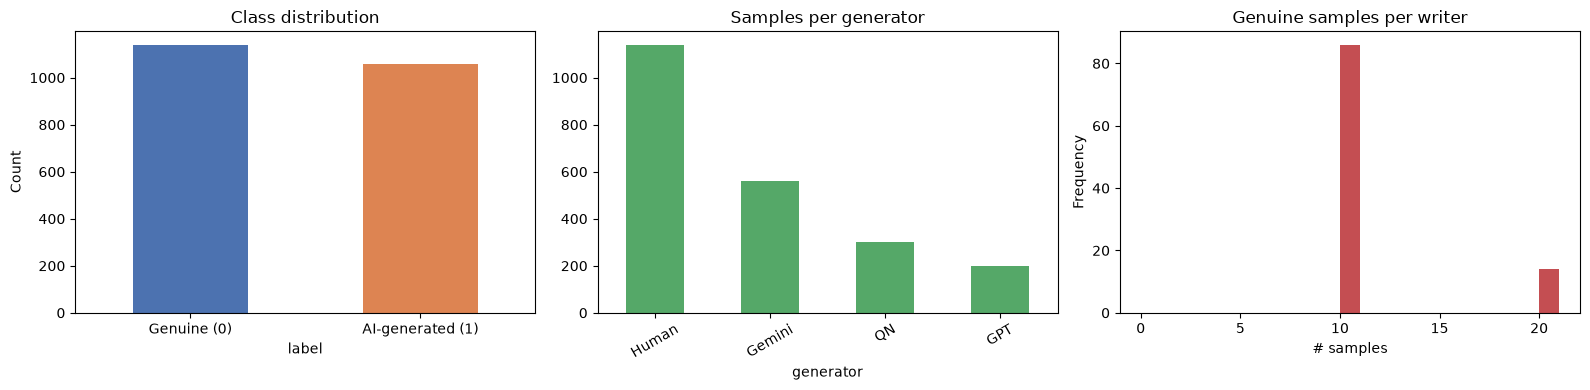

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

generator_counts.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Samples per generator")
axes[1].tick_params(axis="x", rotation=30)

samples_per_writer.plot(kind="hist", bins=range(0, samples_per_writer.max() + 2), ax=axes[2], color="#C44E52")
axes[2].set_title("Genuine samples per writer")
axes[2].set_xlabel("# samples")

plt.tight_layout()
plt.show()


### Class balance note
If genuine vs. AI-generated counts are imbalanced, consider:
- Class-weighted loss during training
- Reporting precision/recall/F1 per class rather than relying on accuracy alone
- Writer-aware (not sample-level) stratified splitting to keep class ratios similar across
  train/val/test — see Notebook 02

## 4. Image dimension, format, and color-mode survey

In [23]:
def image_stats(filepath):
    try:
        with Image.open(filepath) as im:
            w, h = im.size
            mode = im.mode
            fmt = im.format
            file_size_kb = os.path.getsize(filepath) / 1024
        return w, h, mode, fmt, file_size_kb
    except Exception:
        return None, None, None, None, None


stats = df["filepath"].apply(image_stats)
df["width"] = stats.apply(lambda x: x[0])
df["height"] = stats.apply(lambda x: x[1])
df["mode"] = stats.apply(lambda x: x[2])
df["format"] = stats.apply(lambda x: x[3])
df["file_size_kb"] = stats.apply(lambda x: x[4])

bad = df[df["width"].isna()]
if len(bad):
    print(f"WARNING: {len(bad)} files could not be opened:")
    print(bad[["filepath"]])

df[["width", "height", "mode", "format", "file_size_kb"]].describe(include="all")


,width,height,mode,format,file_size_kb
count,2199.000000,2199.000000,2199,2199,2199.000000
unique,NaN,NaN,4,3,NaN
top,NaN,NaN,RGB,TIFF,NaN
freq,NaN,NaN,1047,1140,NaN
mean,926.355161,300.277854,NaN,NaN,180.698864
std,213.798022,41.112582,NaN,NaN,111.748720
min,416.000000,170.000000,NaN,NaN,9.705078
25%,958.000000,280.000000,NaN,NaN,45.648926
50%,999.000000,290.000000,NaN,NaN,255.107422
75%,1051.000000,309.000000,NaN,NaN,283.775391


In [24]:
print("Format counts:\n", df["format"].value_counts(), "\n")
print("Color mode counts:\n", df["mode"].value_counts(), "\n")

print("Format x label crosstab (check for format leaking class info!):")
print(pd.crosstab(df["format"], df["label"]))
print()
print("Color mode x label crosstab (check for mode leaking class info!):")
print(pd.crosstab(df["mode"], df["label"]))
print()
print("Format x generator crosstab:")
print(pd.crosstab(df["format"], df["generator"]))


Format counts:
 format
TIFF    1140
JPEG     735
PNG      324
Name: count, dtype: int64 

Color mode counts:
 mode
RGB     1047
L        872
P        268
RGBA      12
Name: count, dtype: int64 

Format x label crosstab (check for format leaking class info!):
label      0    1
format           
JPEG       0  735
PNG        0  324
TIFF    1140    0

Color mode x label crosstab (check for mode leaking class info!):
label    0     1
mode            
L      872     0
P      268     0
RGB      0  1047
RGBA     0    12

Format x generator crosstab:
generator  GPT  Gemini  Human   QN
format                            
JPEG       198     537      0    0
PNG          0      24      0  300
TIFF         0       0   1140    0


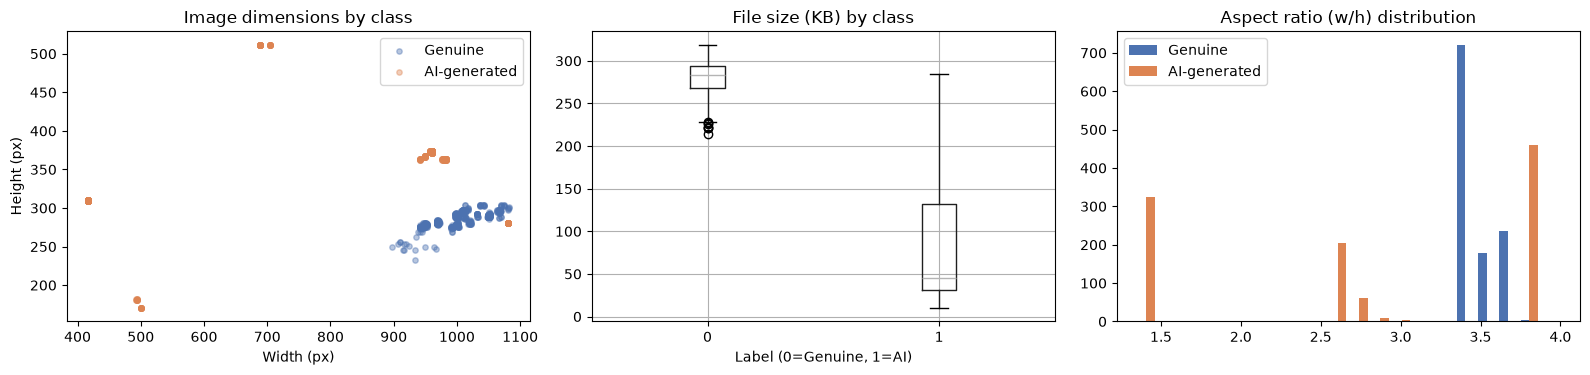

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, name, color in [(0, "Genuine", "#4C72B0"), (1, "AI-generated", "#DD8452")]:
    subset = df[df["label"] == label]
    axes[0].scatter(subset["width"], subset["height"], alpha=0.4, label=name, color=color, s=15)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image dimensions by class")
axes[0].legend()

df.boxplot(column="file_size_kb", by="label", ax=axes[1])
axes[1].set_title("File size (KB) by class")
axes[1].set_xlabel("Label (0=Genuine, 1=AI)")
plt.suptitle("")

aspect_ratio = df["width"] / df["height"]
axes[2].hist([aspect_ratio[df["label"] == 0], aspect_ratio[df["label"] == 1]],
             bins=20, label=["Genuine", "AI-generated"], color=["#4C72B0", "#DD8452"])
axes[2].set_title("Aspect ratio (w/h) distribution")
axes[2].legend()

plt.tight_layout()
plt.show()


**Why this matters:** if genuine and AI-generated images differ systematically in
resolution, aspect ratio, format, or file size, a model can classify on these superficial
cues instead of actual signature characteristics — and per the master note, file format must
**never** be used as a signal (`img = Image.open(path).convert("RGB")` erases it anyway).
Any strong difference found here should be neutralized during preprocessing (Notebook 02).

## 5. Background characteristic analysis

In [26]:
def background_stats(filepath, border_frac=0.05):
    '''Approximate background brightness/uniformity using the image border region.'''
    try:
        with Image.open(filepath).convert("L") as im:
            arr = np.array(im)
        h, w = arr.shape
        bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
        border_pixels = np.concatenate([
            arr[:bh, :].ravel(), arr[-bh:, :].ravel(),
            arr[:, :bw].ravel(), arr[:, -bw:].ravel(),
        ])
        return border_pixels.mean(), border_pixels.std(), arr.mean(), arr.std()
    except Exception:
        return None, None, None, None


bg_stats = df["filepath"].apply(background_stats)
df["bg_mean"] = bg_stats.apply(lambda x: x[0])
df["bg_std"] = bg_stats.apply(lambda x: x[1])
df["img_mean"] = bg_stats.apply(lambda x: x[2])
df["img_std"] = bg_stats.apply(lambda x: x[3])

df.groupby("generator")[["bg_mean", "bg_std", "img_mean", "img_std"]].describe().T


generator              GPT      Gemini        Human          QN
bg_mean  count  198.000000  561.000000  1140.000000  300.000000
         mean   252.462870  238.869304   254.931597  241.606550
         std      3.080811   12.798406     0.271561    6.922065
         min    243.491485  204.719775   251.700212  210.866559
         25%    253.246139  229.399452   255.000000  237.367059
         50%    253.674661  237.531278   255.000000  242.793271
         75%    253.840042  253.360532   255.000000  246.500804
         max    254.208069  255.000000   255.000000  254.065194
bg_std   count  198.000000  561.000000  1140.000000  300.000000
         mean     1.714773   10.353629     1.104362   13.660552
         std      2.549605   10.201070     3.610382   14.225104
         min      0.584351    0.000000     0.000000    0.287153
         25%      0.609677    1.821871     0.000000    3.543219
         50%      0.630485    7.881013     0.000000    7.835278
         75%      0.714799   15.253552     0.000000   20.515124
         max     10.382068   58.456396    28.819390   76.635356
img_mean count  198.000000  561.000000  1140.000000  300.000000
         mean   246.823069  224.823293   247.802429  225.972503
         std      2.207967   12.632243     2.423891    7.243581
         min    240.420112  193.433800   240.468726  201.928639
         25%    246.717814  214.895694   246.209406  221.844312
         50%    247.539406  223.974980   247.988895  226.913931
         75%    248.016798  237.307361   249.661542  231.481310
         max    250.082523  249.860098   252.786788  239.623740
img_std  count  198.000000  561.000000  1140.000000  300.000000
         mean    32.685355   52.969320    41.548285   56.670598
         std      2.315291    6.401378     6.943657    7.851160
         min     25.634458   27.121561    23.653134   31.146112
         25%     31.139359   48.055985    36.507638   50.762156
         50%     32.642821   52.544083    41.551336   56.839640
         75%     34.174977   57.268707    46.450135   61.191446
         max     38.652988   76.238862    59.112748   82.795299

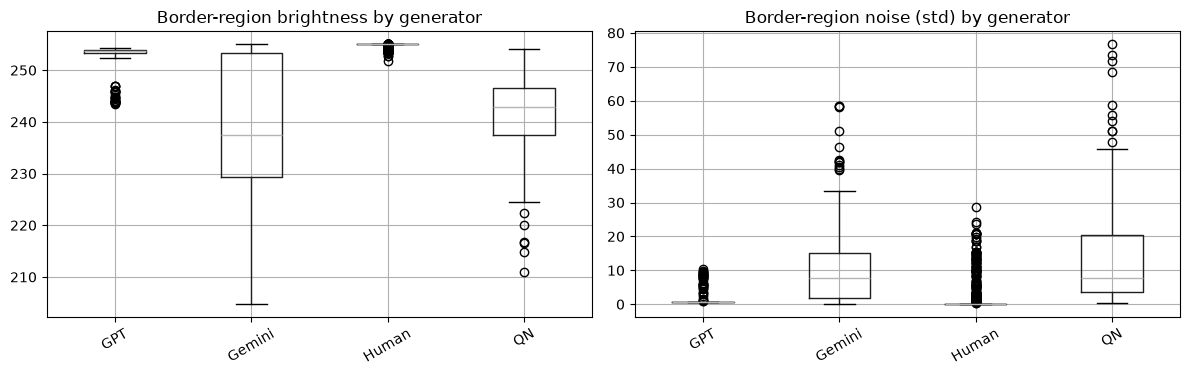

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column="bg_mean", by="generator", ax=axes[0])
axes[0].set_title("Border-region brightness by generator")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

df.boxplot(column="bg_std", by="generator", ax=axes[1])
axes[1].set_title("Border-region noise (std) by generator")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("")
plt.tight_layout()
plt.show()


A large gap in border brightness/noise between generators (e.g. genuine signatures
scanned on slightly off-white/textured paper vs. AI-generated images on a perfectly uniform
white background) is a classic shortcut a CNN will exploit. Notebook 02 includes a
background-normalization step specifically to reduce this gap — and, per the master note,
Experiment 5/12 (reference-based vs no-reference AI) should watch for exactly this kind of
generator-specific artifact when interpreting results.

## 6. Sample signature visualization

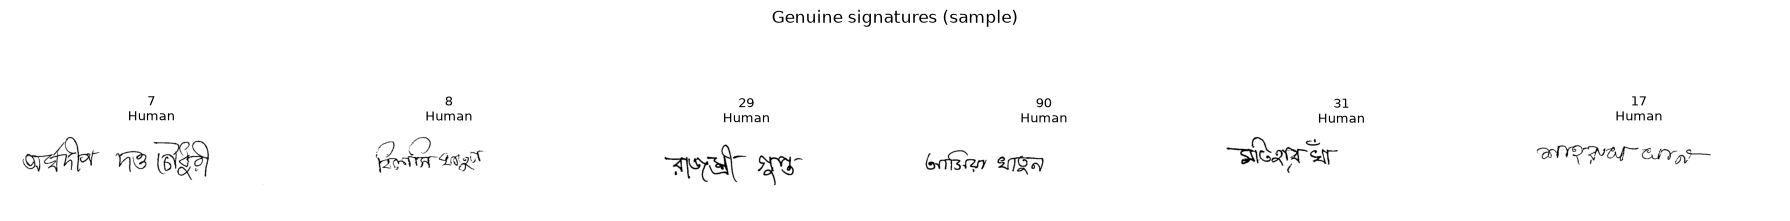

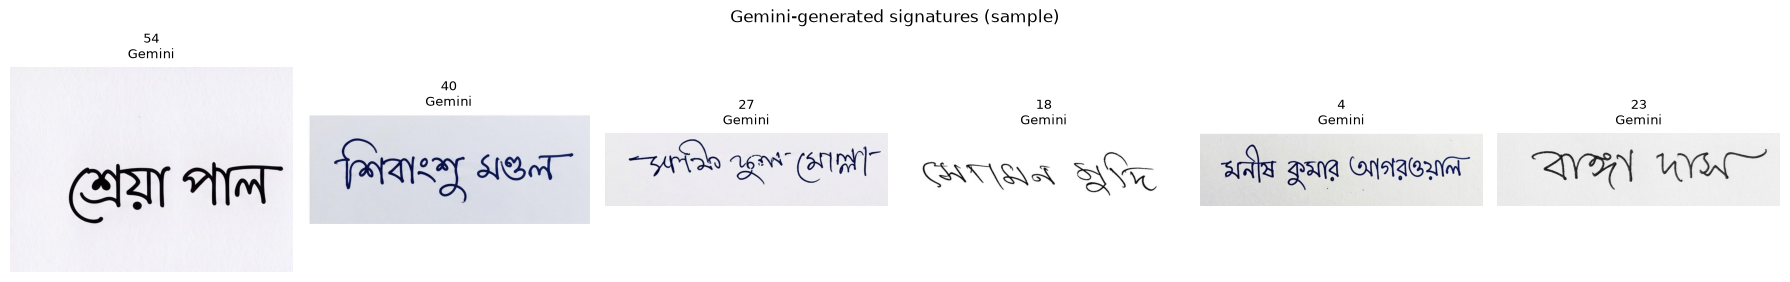

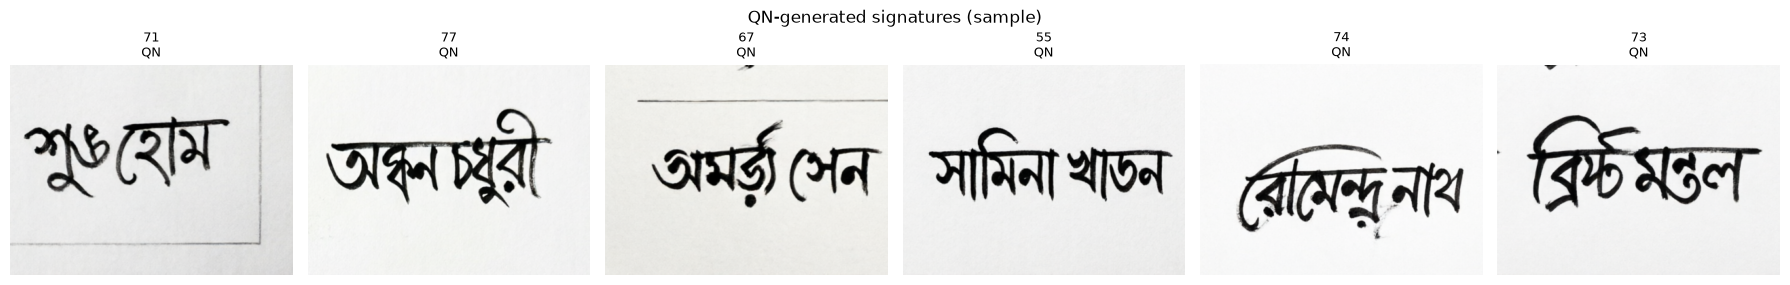

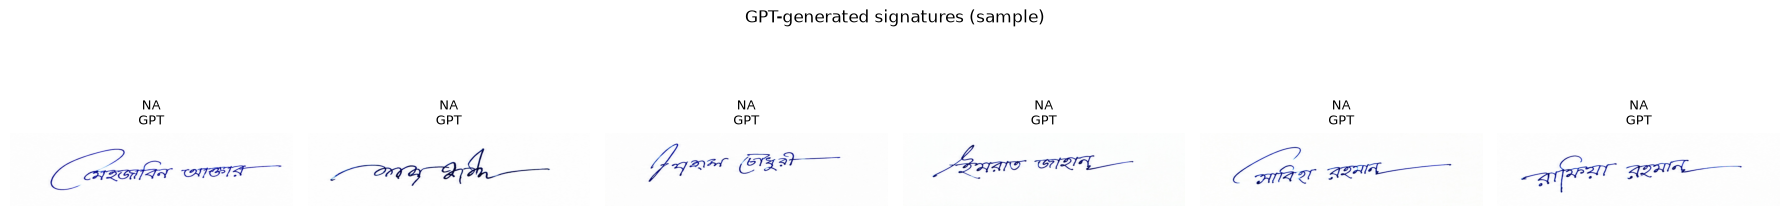

In [28]:
def show_samples(dataframe, n=6, title=""):
    sample = dataframe.sample(min(n, len(dataframe)), random_state=42)
    if len(sample) == 0:
        print(f"[{title}] no samples to show.")
        return
    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, sample.iterrows()):
        try:
            img = Image.open(row["filepath"])
            ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        except Exception:
            ax.text(0.5, 0.5, "load error", ha="center")
        ax.set_title(f"{row['writer_id']}\n{row['generator']}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_samples(df[df["label"] == 0], title="Genuine signatures (sample)")
for gen in [g for g in df["generator"].unique() if g != "Human"]:
    show_samples(df[df["generator"] == gen], title=f"{gen}-generated signatures (sample)")


## 7. Within-writer variation (genuine signatures)

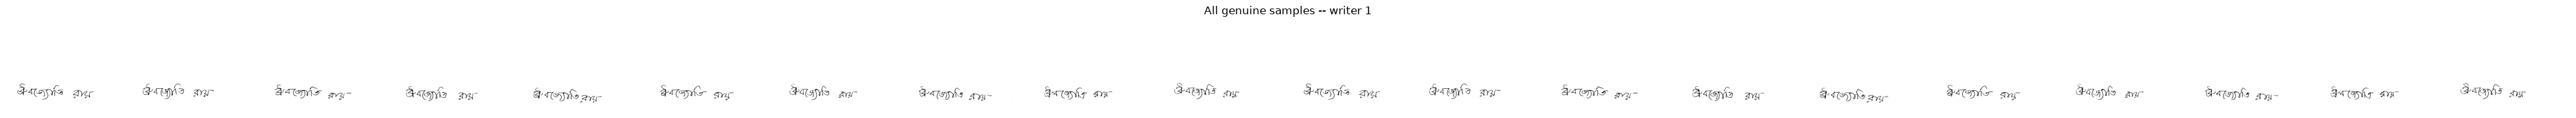

In [29]:
def show_writer_samples(dataframe, writer_id):
    subset = dataframe[(dataframe["writer_id"] == writer_id) & (dataframe["label"] == 0)]
    subset = subset.sort_values("filename")
    fig, axes = plt.subplots(1, len(subset), figsize=(2 * len(subset), 2.5))
    if len(subset) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["filepath"])
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.axis("off")
    fig.suptitle(f"All genuine samples -- writer {writer_id}")
    plt.tight_layout()
    plt.show()


example_writer = df.loc[df["label"] == 0, "writer_id"].dropna().iloc[0]
show_writer_samples(df, example_writer)


Reviewing several writers this way confirms natural intra-writer variation (stroke
pressure, slight shape drift, speed) is present and reasonable — exactly the variation the
model needs to tolerate rather than treat as evidence of "fake." 

## 8. Duplicate / near-duplicate detection

In [30]:
def exact_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def average_hash(filepath, hash_size=8):
    '''Simple perceptual hash (no external deps) for near-duplicate detection.'''
    with Image.open(filepath).convert("L") as im:
        im = im.resize((hash_size, hash_size), Image.LANCZOS)
        arr = np.array(im, dtype=np.float64)
    avg = arr.mean()
    bits = (arr > avg).flatten()
    return "".join("1" if b else "0" for b in bits)


def hamming(a, b):
    return sum(c1 != c2 for c1, c2 in zip(a, b))


df["exact_hash"] = df["filepath"].apply(exact_hash)
exact_dupes = df[df.duplicated("exact_hash", keep=False)].sort_values("exact_hash")
print(f"Exact duplicate files: {len(exact_dupes)} rows "
      f"({exact_dupes['exact_hash'].nunique()} unique groups)")
if len(exact_dupes):
    display(exact_dupes[["filename", "writer_id", "generator", "exact_hash"]])


Exact duplicate files: 329 rows (164 unique groups)


,filename,writer_id,generator,exact_hash
787,7-08.tif,7,Human,0333f8a74b4ff09a45f9990b052700ec
797,B-S-7-G-08.tif,7,Human,0333f8a74b4ff09a45f9990b052700ec
245,27-06.tif,27,Human,08f682179e6353ffc126ba30a5f18a23
235,27-06.tif,26,Human,08f682179e6353ffc126ba30a5f18a23
424,4-05.tif,4,Human,0a540c8c375e06efc2fbf7fc444384df
...,...,...,...,...
16,B-S-1-G-07.tif,1,Human,fd8118d746d7e64bb697482b2eb113bc
428,4-09.tif,4,Human,fe3bce918656f997ac9269c711333001
438,B-S-4-G-09.tif,4,Human,fe3bce918656f997ac9269c711333001
148,B-S-2-G-09.tif,2,Human,fff205e421cd499cf69afec82801d505


In [31]:
# Near-duplicate check via perceptual hash (grouped by writer+generator to keep it fast).
df["phash"] = df["filepath"].apply(average_hash)

near_dupe_pairs = []
THRESHOLD = 5  # lower = stricter; hamming distance out of 64 bits

for (writer, gen), group in df.groupby(["writer_id", "generator"]):
    hashes = group[["filename", "phash"]].values
    for i in range(len(hashes)):
        for j in range(i + 1, len(hashes)):
            d = hamming(hashes[i][1], hashes[j][1])
            if d <= THRESHOLD:
                near_dupe_pairs.append((writer, gen, hashes[i][0], hashes[j][0], d))

near_dupe_df = pd.DataFrame(near_dupe_pairs,
                             columns=["writer_id", "generator", "file_a", "file_b", "hamming_dist"])
print(f"Near-duplicate pairs found (hamming <= {THRESHOLD}): {len(near_dupe_df)}")
near_dupe_df.sort_values("hamming_dist").head(20)


Near-duplicate pairs found (hamming <= 5): 6949


,writer_id,generator,file_a,file_b,hamming_dist
2193,47,Gemini,image_07.jpeg,image_12.jpeg,0
2192,47,Gemini,image_07.jpeg,image_11.jpeg,0
4292,97,Human,97-03.tif,97-07.tif,0
4290,97,Human,97-03.tif,97-05.tif,0
4314,97,Human,97-08.tif,97-09.tif,0
4309,97,Human,97-06.tif,97-09.tif,0
4308,97,Human,97-06.tif,97-08.tif,0
2299,49,Gemini,image_10.jpeg,image_12.jpeg,0
4282,97,Human,97-01.tif,97-04.tif,0
4303,97,Human,97-05.tif,97-07.tif,0


Exact duplicates should be removed before splitting (Notebook 02) — they can leak
identical images across train/test. Near-duplicates within the *same writer* are expected
(natural repeated signing) and fine, as long as writer-level splitting keeps them together.

## 9. Writer-id consistency check (Gemini/QN vs. genuine) — critical for Notebook 02

The master research note flags a specific risk: if Gemini/QN folders were renamed or
renumbered during data collection, the folder-derived `writer_id` may **not** correspond to
the genuine writer the signature was actually referenced from. Writer-disjoint splitting is
only valid if this mapping is real, so we check it here before it becomes a silent bug in the
split notebook.

If you have ground truth (e.g. a `source_human_id` or `original_writer_id` column, or a
mapping file from data collection), load it and compare instead of relying on this heuristic
overlap check alone.

In [32]:
genuine_writer_ids = set(df.loc[df["generator"] == "Human", "writer_id"].unique())

for gen in ["Gemini", "QN"]:
    gen_writer_ids = set(df.loc[df["generator"] == gen, "writer_id"].unique())
    if not gen_writer_ids:
        print(f"{gen}: no samples found, skipping overlap check.")
        continue
    overlap = genuine_writer_ids & gen_writer_ids
    only_in_gen = gen_writer_ids - genuine_writer_ids
    print(f"{gen}: {len(gen_writer_ids)} writer folders, "
          f"{len(overlap)} overlap with genuine writer ids, "
          f"{len(only_in_gen)} have NO matching genuine writer id.")
    if only_in_gen:
        print(f"  -> writer ids present in {gen} but not in genuine/: {sorted(only_in_gen)[:20]}"
              f"{' ...' if len(only_in_gen) > 20 else ''}")
        print(f"  -> INVESTIGATE before Notebook 02: these {gen} folders cannot be writer-linked "
              f"to a genuine writer using the current naming convention.")


Gemini: 54 writer folders, 54 overlap with genuine writer ids, 0 have NO matching genuine writer id.
QN: 25 writer folders, 25 overlap with genuine writer ids, 0 have NO matching genuine writer id.


## 10. Summary report

In [33]:
summary = {
    "Total images": len(df),
    "Genuine images": int((df["label"] == 0).sum()),
    "AI-generated images": int((df["label"] == 1).sum()),
    "Gemini images": int((df["generator"] == "Gemini").sum()),
    "QN images": int((df["generator"] == "QN").sum()),
    "GPT images": int((df["generator"] == "GPT").sum()),
    "Unique genuine writers": int(n_genuine_writers),
    "Exact duplicate rows": int(len(exact_dupes)),
    "Near-duplicate pairs (cross-file)": int(len(near_dupe_df)),
    "Image formats seen": ", ".join(df["format"].dropna().unique()),
    "Color modes seen": ", ".join(df["mode"].dropna().unique()),
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df


,Metric,Value
0,Total images,2199
1,Genuine images,1140
2,AI-generated images,1059
3,Gemini images,561
4,QN images,300
5,GPT images,198
6,Unique genuine writers,100
7,Exact duplicate rows,329
8,Near-duplicate pairs (cross-file),6949
9,Image formats seen,"TIFF, JPEG, PNG"


In [34]:
# Persist the enriched metadata (with image stats) for reference.
# Note: this is an analysis artifact, NOT the split-ready metadata used for training --
# that is produced in Notebook 02 (Preprocessing).
OUT_PATH = DATASET_ROOT / "metadata_with_eda_stats.csv"
df.to_csv(OUT_PATH, index=False)
print(f"Saved enriched metadata to {OUT_PATH}")


Saved enriched metadata to ..\dataset\metadata_with_eda_stats.csv


## Key takeaways to carry into preprocessing

- [ ] Record any systematic width/height/format/background differences found above — these
      need to be neutralized in Notebook 02 so the model can't use them as shortcuts.
- [ ] Remove exact duplicates before splitting.
- [ ] Resolve any writer-id mismatches flagged in Section 9 **before** writer-disjoint
      splitting — an unresolved mismatch there silently breaks the leakage guarantee.
- [ ] Note the class balance (see Section 3) for later loss weighting / metric reporting
      decisions.
- [ ] If QN/Qwen data isn't present yet, re-run this notebook once it's added — no code
      changes needed, it's auto-detected.